In [6]:
!pip install langgraph
!pip install langchain
!pip install langchain_openai


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.6 MB 172.5 kB/s eta 0:00:07
   ------------------- -------------------- 0.8/1.6 MB 280.8 kB/s eta 0:00:04
   -------------


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from langgraph.graph import START, END, StateGraph
from langchain_openai import ChatOpenAI
print('ok')

ok


In [9]:
!pip install dotenv


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from dotenv import load_dotenv
from typing import TypedDict

In [3]:
import os
load_dotenv(override=True)

True

In [4]:
def get_groq_llm():
    return ChatOpenAI(
        model= "openai/gpt-oss-120b",
        base_url= "https://api.groq.com/openai/v1",
        api_key= os.getenv("GROQ_API_KEY"),
        model_kwargs= {"temperature": 0.7},
        max_tokens= 1000,
        )
    
llm= get_groq_llm()
print("loaded groq llm")

C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\IPython\core\interactiveshell.py:3748: UserWarning: Parameters {'temperature'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  exec(code_obj, self.user_global_ns, self.user_ns)


loaded groq llm


In [5]:
class LLMState(TypedDict):
    question: str
    answer: str

In [6]:
def chat_llm(state: LLMState):
    question= state['question']
    
    prompt= f"Answer the following question{question}"

    answer= llm.invoke(prompt).content
    state['answer']= answer
    return state

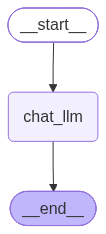

In [7]:
graph= StateGraph(LLMState)

# Add node
graph.add_node('chat_llm', chat_llm)

# Add edge
graph.add_edge(START,'chat_llm')
graph.add_edge('chat_llm', END)

workflow= graph.compile()
workflow


In [8]:
intial_state={'question':'How far is the moon from earth'}

final_state= workflow.invoke(intial_state)

print(final_state)

{'question': 'How far is the moon from earth', 'answer': 'The Moon’s distance from Earth isn’t a single fixed number because its orbit is slightly elliptical.  \n\n**Average (mean) distance:**  \n- **≈\u202f384\u202f400\u202fkm** (about **238\u202f900\u202fmi**)  \n\n**Range of distances:**  \n- **Perigee (closest point):** about **363\u202f300\u202fkm** (≈\u202f225\u202f600\u202fmi)  \n- **Apogee (farthest point):** about **405\u202f500\u202fkm** (≈\u202f251\u202f900\u202fmi)  \n\nSo, on average the Moon is roughly 384\u202f000\u202fkilometers away from Earth, with the actual distance varying by a few tens of thousands of kilometers over each monthly orbit.'}


In [9]:
print(final_state['answer'])

The Moon’s distance from Earth isn’t a single fixed number because its orbit is slightly elliptical.  

**Average (mean) distance:**  
- **≈ 384 400 km** (about **238 900 mi**)  

**Range of distances:**  
- **Perigee (closest point):** about **363 300 km** (≈ 225 600 mi)  
- **Apogee (farthest point):** about **405 500 km** (≈ 251 900 mi)  

So, on average the Moon is roughly 384 000 kilometers away from Earth, with the actual distance varying by a few tens of thousands of kilometers over each monthly orbit.


In [10]:
intial_state={'question':'ok great but how far from sun?'}

final_state= workflow.invoke(intial_state)

print(final_state)

{'question': 'ok great but how far from sun?', 'answer': 'Sure thing! Here’s a quick reference for how far each planet (and a few other interesting objects) sits from the Sun. Distances are given both in **astronomical units (AU)** – where\u202f1\u202fAU is the average distance from the Earth to the Sun – and in **kilometers (km)** for a more concrete feel.\n\n| Object | Average distance from the Sun | Distance in AU | Distance in km (≈) |\n|--------|------------------------------|----------------|-------------------|\n| **Mercury** | 57.9\u202fmillion km | 0.387\u202fAU | 5.79\u202f×\u202f10⁷\u202fkm |\n| **Venus**   | 108.2\u202fmillion km | 0.723\u202fAU | 1.08\u202f×\u202f10⁸\u202fkm |\n| **Earth**   | 149.6\u202fmillion km | 1.000\u202fAU | 1.50\u202f×\u202f10⁸\u202fkm |\n| **Mars**    | 227.9\u202fmillion km | 1.524\u202fAU | 2.28\u202f×\u202f10⁸\u202fkm |\n| **Jupiter** | 778.5\u202fmillion km | 5.204\u202fAU | 7.79\u202f×\u202f10⁸\u202fkm |\n| **Saturn**  | 1.43\u202fbillion km

In [11]:

print(final_state['answer'])

Sure thing! Here’s a quick reference for how far each planet (and a few other interesting objects) sits from the Sun. Distances are given both in **astronomical units (AU)** – where 1 AU is the average distance from the Earth to the Sun – and in **kilometers (km)** for a more concrete feel.

| Object | Average distance from the Sun | Distance in AU | Distance in km (≈) |
|--------|------------------------------|----------------|-------------------|
| **Mercury** | 57.9 million km | 0.387 AU | 5.79 × 10⁷ km |
| **Venus**   | 108.2 million km | 0.723 AU | 1.08 × 10⁸ km |
| **Earth**   | 149.6 million km | 1.000 AU | 1.50 × 10⁸ km |
| **Mars**    | 227.9 million km | 1.524 AU | 2.28 × 10⁸ km |
| **Jupiter** | 778.5 million km | 5.204 AU | 7.79 × 10⁸ km |
| **Saturn**  | 1.43 billion km   | 9.582 AU | 1.43 × 10⁹ km |
| **Uranus**  | 2.87 billion km   | 19.20 AU | 2.87 × 10⁹ km |
| **Neptune** | 4.50 billion km   | 30.05 AU | 4.50 × 10⁹ km |
| **Pluto** (dwarf) | 5.91 billion km | 39.48 AU 

### Stateless calls: It does not have any previous message history 

In [ ]:
## Call to LLM

user_q1: "how far moon from earth?"
llm: answer 
    
user_q2: "follow up question"
llm: proper answer
     